<a href="https://colab.research.google.com/github/terry0809000/NLP-KCL/blob/main/nlpassessment0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

train_df = pd.read_csv(
    "/content/drive/MyDrive/train.txt",
    sep="\t",
    header=None,
    names=["pmid","label","text"]
)

dev_df = pd.read_csv(
    "/content/drive/MyDrive/dev.txt",
    sep="\t",
    header=None,
    names=["pmid","label","text"]
)

test_df = pd.read_csv(
    "/content/drive/MyDrive/test.txt",
    sep="\t",
    header=None,
    names=["pmid","label","text"]
)

In [38]:
# Optional installs for Colab (uncomment if needed)
!pip install -q transformers datasets accelerate evaluate scikit-learn seaborn

import os
import re
import time
import math
import json
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.txt"
DEV_PATH = DATA_DIR / "dev.txt"
TEST_PATH = DATA_DIR / "test.txt"

LABEL_ORDER = ["BACKGROUND", "OBJECTIVE", "METHODS", "RESULTS", "CONCLUSIONS"]
LABEL2ID = {label: i for i, label in enumerate(LABEL_ORDER)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

print("Setup complete.")
print(f"Working directory: {DATA_DIR.resolve()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
Setup complete.
Working directory: /content


In [5]:
def summarize_split(df: pd.DataFrame, split_name: str) -> pd.Series:
    abstract_lengths = df.groupby("pmid").size()
    return pd.Series({
        "split": split_name,
        "n_sentences": len(df),
        "n_unique_pmids": df["pmid"].nunique(),
        "avg_sentences_per_abstract": abstract_lengths.mean(),
        "median_sentences_per_abstract": abstract_lengths.median(),
        "min_sentences_per_abstract": abstract_lengths.min(),
        "max_sentences_per_abstract": abstract_lengths.max(),
    })

eda_summary = pd.DataFrame([
    summarize_split(train_df, "train"),
    summarize_split(dev_df, "dev"),
    summarize_split(test_df, "test"),
])
eda_summary

,split,n_sentences,n_unique_pmids,avg_sentences_per_abstract,median_sentences_per_abstract,min_sentences_per_abstract,max_sentences_per_abstract
0,train,180040,15000,12.002667,12.0,4,31
1,dev,30212,2500,12.084800,12.0,4,27
2,test,30135,2500,12.054000,12.0,4,28


split,dev,test,train
label,,,
BACKGROUND,3449,3621,21727
OBJECTIVE,2376,2333,13839
METHODS,9964,9897,59353
RESULTS,9841,9713,57953
CONCLUSIONS,4582,4571,27168


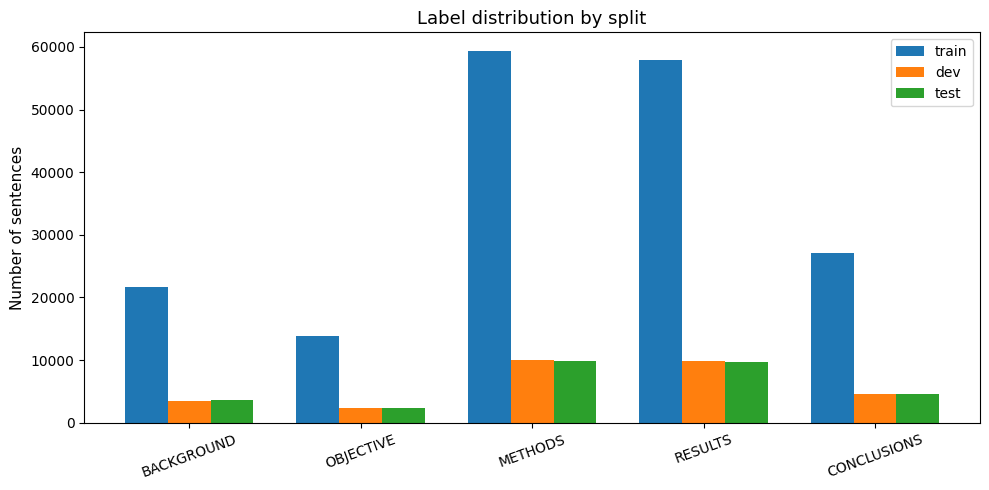

In [8]:
train_df['split'] = 'train'
dev_df['split'] = 'dev'
test_df['split'] = 'test'

label_dist = (
    pd.concat([train_df, dev_df, test_df], axis=0)
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
)
label_pivot = label_dist.pivot(index="label", columns="split", values="count").reindex(LABEL_ORDER)
display(label_pivot)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(LABEL_ORDER))
width = 0.25
for i, split_name in enumerate(["train", "dev", "test"]):
    counts = label_pivot[split_name].values
    ax.bar(x + (i - 1) * width, counts, width=width, label=split_name)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_ORDER, rotation=20)
ax.set_title("Label distribution by split")
ax.set_ylabel("Number of sentences")
ax.legend()
plt.tight_layout()
plt.show()

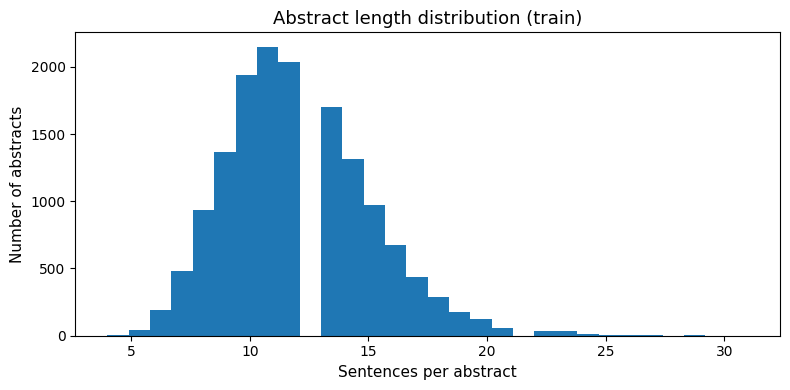

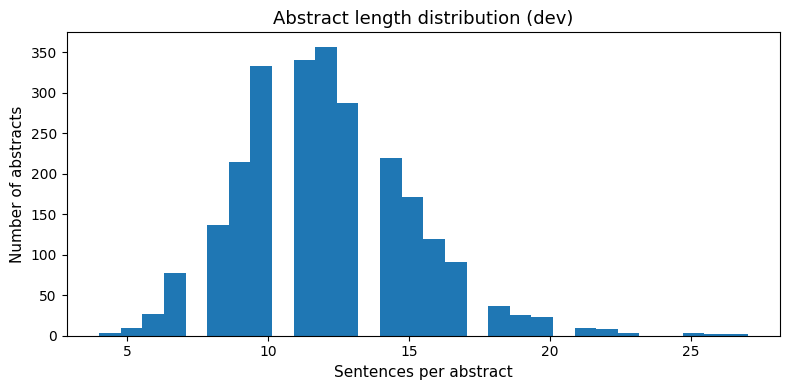

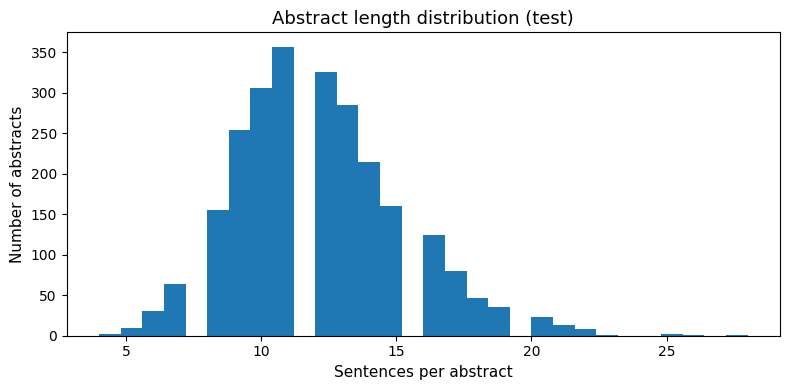

In [9]:
def plot_abstract_length_distribution(df: pd.DataFrame, split_name: str, bins: int = 30):
    lengths = df.groupby("pmid").size()
    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=bins)
    plt.title(f"Abstract length distribution ({split_name})")
    plt.xlabel("Sentences per abstract")
    plt.ylabel("Number of abstracts")
    plt.tight_layout()
    plt.show()

for split_name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    plot_abstract_length_distribution(df, split_name)

In [11]:
def reconstruct_abstracts(df: pd.DataFrame) -> pd.DataFrame:
    # Ensure 'sent_idx' is present for sorting
    # It's safer to add it here or make sure it's present in the input df
    # However, for this specific error, we need to add it before calling this function.
    grouped = (
        df.sort_values(["pmid", "sent_idx"])
          .groupby("pmid")
          .agg(
              abstract_text=("text", lambda x: " ".join(x)),
              labels=("label", list),
              n_sentences=("text", "size"),
          )
          .reset_index()
    )
    return grouped

# Add a 'sent_idx' column to each DataFrame before reconstruction
train_df['sent_idx'] = train_df.groupby('pmid').cumcount()
dev_df['sent_idx'] = dev_df.groupby('pmid').cumcount()
test_df['sent_idx'] = test_df.groupby('pmid').cumcount()

train_abstracts = reconstruct_abstracts(train_df)
dev_abstracts = reconstruct_abstracts(dev_df)
test_abstracts = reconstruct_abstracts(test_df)

print("Reconstructed abstract tables:")
print(train_abstracts.head(2))

Reconstructed abstract tables:
       pmid                                      abstract_text  \
0  24219770  The purpose of this study was to determine the...   
1  24219814  Repeated courses of intravenous ( IV ) aminogl...   

                                              labels  n_sentences  
0  [OBJECTIVE, METHODS, METHODS, RESULTS, RESULTS...            9  
1  [BACKGROUND, BACKGROUND, METHODS, METHODS, RES...            9  


In [12]:
def show_sample_abstracts(df: pd.DataFrame, n_pmids: int = 3, seed: int = SEED):
    rng = np.random.default_rng(seed)
    sampled_pmids = rng.choice(df["pmid"].unique(), size=min(n_pmids, df["pmid"].nunique()), replace=False)
    for pmid in sampled_pmids:
        sub = df[df["pmid"] == pmid].sort_values("sent_idx")
        print("=" * 100)
        print(f"PMID: {pmid} | n_sentences: {len(sub)}")
        print("-" * 100)
        for _, row in sub.iterrows():
            print(f"[{row['sent_idx']:02d}] {row['label']:<12} {row['text']}")
        print()

show_sample_abstracts(train_df, n_pmids=3, seed=SEED)

PMID: 26016365 | n_sentences: 19
----------------------------------------------------------------------------------------------------
[00] OBJECTIVE    This study was aimed to explore the physiological changes and the effect of heat acclimation training via a randomized control trial study .
[01] METHODS      Forty healthy male volunteers were chosen and divided into experimental group and control group randomly .
[02] METHODS      Those in experimental group received heat acclimation training including but not limited to meditation , unarmed run , yoga , and stepping in hot lab environment .
[03] METHODS      And then , subjective feeling , rectal temperature , average skin temperature , and sweat electrolytes concentration were detected in order to describe their physiological changes .
[04] METHODS      Before and after the training , both groups received some tests and their 3 000 m run-race time , nervous reaction time and subjective perception scores were recorded to evaluate the

In [13]:
NUM_PATTERN = re.compile(
    r"""
    (?<![A-Za-z<])
    [+-]?
    (?:
        \d+\.\d+ |
        \d+
    )
    (?:\s?%|\s?[A-Za-z]+(?:/[A-Za-z]+)?)?
    """,
    re.VERBOSE,
)

def normalize_numbers(text: str, token: str = "<NUM>") -> str:
    text = str(text)
    return NUM_PATTERN.sub(token, text)

def preprocess_text_series(text_series: pd.Series, number_normalize: bool = False) -> pd.Series:
    x = text_series.astype(str).copy()
    if number_normalize:
        x = x.apply(normalize_numbers)
    return x

demo_examples = pd.Series([
    "We enrolled 250 patients over 12 months.",
    "The dose was 5 mg daily and response improved by 22.5%.",
    "P = 0.03 in the intervention group.",
])
pd.DataFrame({
    "original": demo_examples,
    "normalized": demo_examples.apply(normalize_numbers),
})

,original,normalized
0,We enrolled 250 patients over 12 months.,We enrolled <NUM> over <NUM>.
1,The dose was 5 mg daily and response improved ...,The dose was <NUM> daily and response improved...
2,P = 0.03 in the intervention group.,P = <NUM> the intervention group.


In [14]:
def compute_metrics(y_true, y_pred, labels=LABEL_ORDER) -> dict:
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels)
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, s = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    per_class_df = pd.DataFrame({
        "label": labels,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": s,
    })
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "per_class": per_class_df,
    }

def print_metrics_block(name: str, metrics_dict: dict):
    print(name)
    print("-" * len(name))
    print(f"Accuracy    : {metrics_dict['accuracy']:.4f}")
    print(f"Macro-F1    : {metrics_dict['macro_f1']:.4f}")
    print(f"Weighted-F1 : {metrics_dict['weighted_f1']:.4f}")
    print()
    display(metrics_dict["per_class"].style.format({
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
    }))

def plot_confusion_matrix(y_true, y_pred, labels=LABEL_ORDER, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def timed_predict(model, X):
    start = time.perf_counter()
    preds = model.predict(X)
    elapsed = time.perf_counter() - start
    return preds, elapsed

experiment_rows = []
saved_predictions = {}
saved_models = {}

def register_result(
    model_name: str,
    preprocessing: str,
    uses_sequential: str,
    dev_metrics: dict,
    test_metrics: dict,
    train_time: float,
    dev_infer_time: float,
    test_infer_time: float,
):
    experiment_rows.append({
        "model_name": model_name,
        "preprocessing": preprocessing,
        "uses_sequential_info": uses_sequential,
        "dev_macro_f1": dev_metrics["macro_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "dev_accuracy": dev_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "dev_weighted_f1": dev_metrics["weighted_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "training_time_sec": train_time,
        "dev_inference_time_sec": dev_infer_time,
        "test_inference_time_sec": test_infer_time,
    })

In [15]:
def majority_class_baseline(train_df, dev_df, test_df):
    majority_label = train_df["label"].value_counts().idxmax()
    print(f"Majority training label: {majority_label}")

    start_train = time.perf_counter()
    time.sleep(0.0001)
    train_time = time.perf_counter() - start_train

    start_dev = time.perf_counter()
    dev_pred = np.array([majority_label] * len(dev_df))
    dev_infer = time.perf_counter() - start_dev

    start_test = time.perf_counter()
    test_pred = np.array([majority_label] * len(test_df))
    test_infer = time.perf_counter() - start_test

    dev_metrics = compute_metrics(dev_df["label"], dev_pred)
    test_metrics = compute_metrics(test_df["label"], test_pred)

    register_result(
        model_name="A. Majority baseline",
        preprocessing="None",
        uses_sequential="No",
        dev_metrics=dev_metrics,
        test_metrics=test_metrics,
        train_time=train_time,
        dev_infer_time=dev_infer,
        test_infer_time=test_infer,
    )

    saved_predictions["A. Majority baseline"] = {
        "dev_pred": dev_pred,
        "test_pred": test_pred,
    }
    return dev_metrics, test_metrics

maj_dev_metrics, maj_test_metrics = majority_class_baseline(train_df, dev_df, test_df)
print_metrics_block("Majority baseline — dev", maj_dev_metrics)
print_metrics_block("Majority baseline — test", maj_test_metrics)

Majority training label: METHODS
Majority baseline — dev
-----------------------
Accuracy    : 0.3298
Macro-F1    : 0.0992
Weighted-F1 : 0.1636



,label,precision,recall,f1,support
0,BACKGROUND,0.000,0.000,0.000,3449
1,OBJECTIVE,0.000,0.000,0.000,2376
2,METHODS,0.330,1.000,0.496,9964
3,RESULTS,0.000,0.000,0.000,9841
4,CONCLUSIONS,0.000,0.000,0.000,4582


Majority baseline — test
------------------------
Accuracy    : 0.3284
Macro-F1    : 0.0989
Weighted-F1 : 0.1624



,label,precision,recall,f1,support
0,BACKGROUND,0.000,0.000,0.000,3621
1,OBJECTIVE,0.000,0.000,0.000,2333
2,METHODS,0.328,1.000,0.494,9897
3,RESULTS,0.000,0.000,0.000,9713
4,CONCLUSIONS,0.000,0.000,0.000,4571


In [16]:
def make_tfidf_lr_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            lowercase=True,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            random_state=SEED,
            multi_class="auto",
        )),
    ])

def make_tfidf_svm_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            lowercase=True,
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        )),
        ("clf", LinearSVC()),
    ])

def run_sklearn_experiment(
    model_name: str,
    pipeline,
    train_df: pd.DataFrame,
    dev_df: pd.DataFrame,
    test_df: pd.DataFrame,
    number_normalize: bool = False,
):
    X_train = preprocess_text_series(train_df["text"], number_normalize=number_normalize)
    X_dev = preprocess_text_series(dev_df["text"], number_normalize=number_normalize)
    X_test = preprocess_text_series(test_df["text"], number_normalize=number_normalize)

    y_train = train_df["label"].values
    y_dev = dev_df["label"].values
    y_test = test_df["label"].values

    start_train = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    dev_pred, dev_infer = timed_predict(pipeline, X_dev)
    test_pred, test_infer = timed_predict(pipeline, X_test)

    dev_metrics = compute_metrics(y_dev, dev_pred)
    test_metrics = compute_metrics(y_test, test_pred)

    register_result(
        model_name=model_name,
        preprocessing="Number normalization" if number_normalize else "Minimal",
        uses_sequential="No",
        dev_metrics=dev_metrics,
        test_metrics=test_metrics,
        train_time=train_time,
        dev_infer_time=dev_infer,
        test_infer_time=test_infer,
    )

    saved_models[model_name] = pipeline
    saved_predictions[model_name] = {
        "dev_pred": dev_pred,
        "test_pred": test_pred,
    }
    return pipeline, dev_metrics, test_metrics

In [17]:
tfidf_lr_model, tfidf_lr_dev, tfidf_lr_test = run_sklearn_experiment(
    model_name="B. TF-IDF + Logistic Regression",
    pipeline=make_tfidf_lr_pipeline(),
    train_df=train_df,
    dev_df=dev_df,
    test_df=test_df,
    number_normalize=False,
)

print_metrics_block("B. TF-IDF + Logistic Regression — dev", tfidf_lr_dev)
print_metrics_block("B. TF-IDF + Logistic Regression — test", tfidf_lr_test)

B. TF-IDF + Logistic Regression — dev
-------------------------------------
Accuracy    : 0.8319
Macro-F1    : 0.7689
Weighted-F1 : 0.8291



,label,precision,recall,f1,support
0,BACKGROUND,0.663,0.658,0.660,3449
1,OBJECTIVE,0.726,0.548,0.625,2376
2,METHODS,0.878,0.930,0.903,9964
3,RESULTS,0.892,0.894,0.893,9841
4,CONCLUSIONS,0.764,0.763,0.763,4582


B. TF-IDF + Logistic Regression — test
--------------------------------------
Accuracy    : 0.8243
Macro-F1    : 0.7616
Weighted-F1 : 0.8212



,label,precision,recall,f1,support
0,BACKGROUND,0.668,0.652,0.660,3621
1,OBJECTIVE,0.708,0.538,0.611,2333
2,METHODS,0.869,0.930,0.898,9897
3,RESULTS,0.886,0.884,0.885,9713
4,CONCLUSIONS,0.755,0.751,0.753,4571


In [18]:
tfidf_svm_model, tfidf_svm_dev, tfidf_svm_test = run_sklearn_experiment(
    model_name="C. TF-IDF + Linear SVM",
    pipeline=make_tfidf_svm_pipeline(),
    train_df=train_df,
    dev_df=dev_df,
    test_df=test_df,
    number_normalize=False,
)

print_metrics_block("C. TF-IDF + Linear SVM — dev", tfidf_svm_dev)
print_metrics_block("C. TF-IDF + Linear SVM — test", tfidf_svm_test)

C. TF-IDF + Linear SVM — dev
----------------------------
Accuracy    : 0.8324
Macro-F1    : 0.7695
Weighted-F1 : 0.8302



,label,precision,recall,f1,support
0,BACKGROUND,0.663,0.663,0.663,3449
1,OBJECTIVE,0.688,0.564,0.619,2376
2,METHODS,0.887,0.927,0.907,9964
3,RESULTS,0.889,0.894,0.892,9841
4,CONCLUSIONS,0.774,0.759,0.767,4582


C. TF-IDF + Linear SVM — test
-----------------------------
Accuracy    : 0.8225
Macro-F1    : 0.7587
Weighted-F1 : 0.8201



,label,precision,recall,f1,support
0,BACKGROUND,0.658,0.648,0.653,3621
1,OBJECTIVE,0.668,0.553,0.605,2333
2,METHODS,0.880,0.923,0.901,9897
3,RESULTS,0.883,0.887,0.885,9713
4,CONCLUSIONS,0.756,0.744,0.750,4571


In [19]:
tfidf_lr_num_model, tfidf_lr_num_dev, tfidf_lr_num_test = run_sklearn_experiment(
    model_name="D. TF-IDF + Logistic Regression + <NUM>",
    pipeline=make_tfidf_lr_pipeline(),
    train_df=train_df,
    dev_df=dev_df,
    test_df=test_df,
    number_normalize=True,
)

print_metrics_block("D. TF-IDF + Logistic Regression + <NUM> — dev", tfidf_lr_num_dev)
print_metrics_block("D. TF-IDF + Logistic Regression + <NUM> — test", tfidf_lr_num_test)

D. TF-IDF + Logistic Regression + <NUM> — dev
---------------------------------------------
Accuracy    : 0.8327
Macro-F1    : 0.7708
Weighted-F1 : 0.8301



,label,precision,recall,f1,support
0,BACKGROUND,0.670,0.677,0.673,3449
1,OBJECTIVE,0.734,0.541,0.623,2376
2,METHODS,0.883,0.926,0.904,9964
3,RESULTS,0.889,0.895,0.892,9841
4,CONCLUSIONS,0.758,0.765,0.762,4582


D. TF-IDF + Logistic Regression + <NUM> — test
----------------------------------------------
Accuracy    : 0.8257
Macro-F1    : 0.7645
Weighted-F1 : 0.8228



,label,precision,recall,f1,support
0,BACKGROUND,0.673,0.669,0.671,3621
1,OBJECTIVE,0.716,0.539,0.615,2333
2,METHODS,0.875,0.926,0.900,9897
3,RESULTS,0.882,0.886,0.884,9713
4,CONCLUSIONS,0.755,0.752,0.753,4571


In [20]:
try:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
        set_seed,
    )
    TRANSFORMERS_AVAILABLE = True
except Exception as e:
    TRANSFORMERS_AVAILABLE = False
    print("Transformers stack not available.")
    print("Install with: pip install transformers datasets accelerate")
    print(f"Import error: {e}")

In [21]:
def sample_training_subset(df: pd.DataFrame, fraction: float = 0.35, seed: int = SEED) -> pd.DataFrame:
    """Stratified sentence-level subset for compute efficiency within the training split."""
    if fraction >= 1.0:
        return df.copy()
    sampled = (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(frac=fraction, random_state=seed))
          .sort_index()
          .reset_index(drop=True)
    )
    sampled["sent_idx"] = sampled.groupby("pmid").cumcount()
    return sampled

def make_hf_dataset(df: pd.DataFrame, text_col: str = "text_proc"):
    tmp = df.copy()
    tmp["label_id"] = tmp["label"].map(LABEL2ID)
    return Dataset.from_pandas(tmp[[text_col, "label_id"]].rename(columns={text_col: "text"}), preserve_index=False)

def scibert_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    y_true = [ID2LABEL[int(i)] for i in labels]
    y_pred = [ID2LABEL[int(i)] for i in preds]
    metrics = compute_metrics(y_true, y_pred)
    return {
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
    }

In [22]:
USE_SUBSET_FOR_SCIBERT = True
SCIBERT_TRAIN_FRACTION = 0.35
SCIBERT_MODEL_NAME = "allenai/scibert_scivocab_uncased"
SCIBERT_MAX_LENGTH = 128
SCIBERT_NUM_EPOCHS = 2
SCIBERT_BATCH_SIZE = 16
SCIBERT_LR = 2e-5

print("SciBERT config:")
print(f"  USE_SUBSET_FOR_SCIBERT = {USE_SUBSET_FOR_SCIBERT}")
print(f"  SCIBERT_TRAIN_FRACTION = {SCIBERT_TRAIN_FRACTION}")
print(f"  MODEL = {SCIBERT_MODEL_NAME}")

SciBERT config:
  USE_SUBSET_FOR_SCIBERT = True
  SCIBERT_TRAIN_FRACTION = 0.35
  MODEL = allenai/scibert_scivocab_uncased


In [23]:
def estimate_label_markov_parameters(train_df: pd.DataFrame, labels=LABEL_ORDER, alpha: float = 1.0):
    n_labels = len(labels)
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    init_counts = np.full(n_labels, alpha, dtype=float)
    trans_counts = np.full((n_labels, n_labels), alpha, dtype=float)

    for _, sub in train_df.sort_values(["pmid", "sent_idx"]).groupby("pmid"):
        seq = sub["label"].tolist()
        if not seq:
            continue
        init_counts[label_to_idx[seq[0]]] += 1
        for a, b in zip(seq[:-1], seq[1:]):
            trans_counts[label_to_idx[a], label_to_idx[b]] += 1

    init_probs = init_counts / init_counts.sum()
    trans_probs = trans_counts / trans_counts.sum(axis=1, keepdims=True)
    return init_probs, trans_probs

def viterbi_decode(emission_probs: np.ndarray, init_probs: np.ndarray, trans_probs: np.ndarray):
    T, K = emission_probs.shape
    log_emit = np.log(np.clip(emission_probs, 1e-12, 1.0))
    log_init = np.log(np.clip(init_probs, 1e-12, 1.0))
    log_trans = np.log(np.clip(trans_probs, 1e-12, 1.0))

    dp = np.zeros((T, K))
    back = np.zeros((T, K), dtype=int)
    dp[0] = log_init + log_emit[0]

    for t in range(1, T):
        for k in range(K):
            scores = dp[t - 1] + log_trans[:, k]
            back[t, k] = np.argmax(scores)
            dp[t, k] = scores[back[t, k]] + log_emit[t, k]

    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(dp[-1])
    for t in range(T - 2, -1, -1):
        path[t] = back[t + 1, path[t + 1]]
    return path

def get_label_probabilities_from_sklearn_model(model: Pipeline, texts: pd.Series) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(texts)
        classes = model.classes_
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(texts)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        classes = model.classes_
    else:
        raise ValueError("Model must support predict_proba or decision_function for sequence decoding.")

    class_idx = {c: i for i, c in enumerate(classes)}
    ordered_probs = np.column_stack([probs[:, class_idx[label]] for label in LABEL_ORDER])
    return ordered_probs

def apply_sequence_decoding(df: pd.DataFrame, base_model: Pipeline, init_probs, trans_probs, number_normalize: bool = False):
    df_use = df.copy().sort_values(["pmid", "sent_idx"]).reset_index(drop=True)
    df_use["text_proc"] = preprocess_text_series(df_use["text"], number_normalize=number_normalize)
    emission_probs = get_label_probabilities_from_sklearn_model(base_model, df_use["text_proc"])

    seq_preds = np.empty(len(df_use), dtype=object)
    for _, idx in df_use.groupby("pmid").groups.items():
        idx = list(idx)
        path = viterbi_decode(emission_probs[idx], init_probs, trans_probs)
        seq_preds[idx] = [ID2LABEL[i] for i in path]
    return df_use, seq_preds

In [24]:
traditional_candidates = [
    row for row in experiment_rows
    if row["model_name"] in {
        "B. TF-IDF + Logistic Regression",
        "C. TF-IDF + Linear SVM",
        "D. TF-IDF + Logistic Regression + <NUM>",
    }
]
best_traditional_row = max(traditional_candidates, key=lambda x: x["dev_macro_f1"])
best_traditional_name = best_traditional_row["model_name"]
best_traditional_model = saved_models[best_traditional_name]
best_traditional_uses_num = best_traditional_name == "D. TF-IDF + Logistic Regression + <NUM>"

print("Best non-sequential traditional model on dev:")
print(best_traditional_name)
print(f"Dev macro-F1 = {best_traditional_row['dev_macro_f1']:.4f}")

Best non-sequential traditional model on dev:
D. TF-IDF + Logistic Regression + <NUM>
Dev macro-F1 = 0.7708


In [25]:
init_probs, trans_probs = estimate_label_markov_parameters(train_df, labels=LABEL_ORDER, alpha=1.0)
print("Initial label probabilities:")
display(pd.DataFrame({"label": LABEL_ORDER, "p_init": init_probs}))

print("Transition matrix:")
display(pd.DataFrame(trans_probs, index=LABEL_ORDER, columns=LABEL_ORDER).style.format("{:.3f}"))

Initial label probabilities:


,label,p_init
0,BACKGROUND,0.492369
1,OBJECTIVE,0.501300
2,METHODS,0.005332
3,RESULTS,0.000067
4,CONCLUSIONS,0.000933


Transition matrix:


,BACKGROUND,OBJECTIVE,METHODS,RESULTS,CONCLUSIONS
BACKGROUND,0.597,0.096,0.288,0.018,0.000
OBJECTIVE,0.017,0.319,0.651,0.013,0.001
METHODS,0.002,0.001,0.753,0.229,0.015
RESULTS,0.000,0.000,0.000,0.758,0.241
CONCLUSIONS,0.173,0.001,0.013,0.001,0.812


In [26]:
start_seq_dev = time.perf_counter()
dev_df_seq, dev_seq_pred = apply_sequence_decoding(
    dev_df,
    base_model=best_traditional_model,
    init_probs=init_probs,
    trans_probs=trans_probs,
    number_normalize=best_traditional_uses_num,
)
dev_seq_infer = time.perf_counter() - start_seq_dev

start_seq_test = time.perf_counter()
test_df_seq, test_seq_pred = apply_sequence_decoding(
    test_df,
    base_model=best_traditional_model,
    init_probs=init_probs,
    trans_probs=trans_probs,
    number_normalize=best_traditional_uses_num,
)
test_seq_infer = time.perf_counter() - start_seq_test

start_transition = time.perf_counter()
_ = estimate_label_markov_parameters(train_df, labels=LABEL_ORDER, alpha=1.0)
seq_train_time = time.perf_counter() - start_transition

seq_dev_metrics = compute_metrics(dev_df_seq["label"], dev_seq_pred)
seq_test_metrics = compute_metrics(test_df_seq["label"], test_seq_pred)

register_result(
    model_name=f"F. Sequence-aware Viterbi on top of {best_traditional_name}",
    preprocessing="Inherited from base model",
    uses_sequential="Yes",
    dev_metrics=seq_dev_metrics,
    test_metrics=seq_test_metrics,
    train_time=seq_train_time,
    dev_infer_time=dev_seq_infer,
    test_infer_time=test_seq_infer,
)

saved_predictions[f"F. Sequence-aware Viterbi on top of {best_traditional_name}"] = {
    "dev_pred": dev_seq_pred,
    "test_pred": test_seq_pred,
}

print_metrics_block("F. Sequence-aware decoding — dev", seq_dev_metrics)
print_metrics_block("F. Sequence-aware decoding — test", seq_test_metrics)

F. Sequence-aware decoding — dev
--------------------------------
Accuracy    : 0.8759
Macro-F1    : 0.8195
Weighted-F1 : 0.8727



,label,precision,recall,f1,support
0,BACKGROUND,0.728,0.801,0.763,3449
1,OBJECTIVE,0.758,0.529,0.623,2376
2,METHODS,0.905,0.965,0.934,9964
3,RESULTS,0.900,0.926,0.913,9841
4,CONCLUSIONS,0.927,0.810,0.865,4582


F. Sequence-aware decoding — test
---------------------------------
Accuracy    : 0.8708
Macro-F1    : 0.8130
Weighted-F1 : 0.8672



,label,precision,recall,f1,support
0,BACKGROUND,0.731,0.795,0.762,3621
1,OBJECTIVE,0.740,0.511,0.604,2333
2,METHODS,0.895,0.964,0.928,9897
3,RESULTS,0.901,0.921,0.911,9713
4,CONCLUSIONS,0.923,0.805,0.860,4571


In [27]:
base_dev_pred = saved_predictions[best_traditional_name]["dev_pred"]
base_test_pred = saved_predictions[best_traditional_name]["test_pred"]

base_dev_metrics = compute_metrics(dev_df["label"], base_dev_pred)
base_test_metrics = compute_metrics(test_df["label"], base_test_pred)

comparison_df = pd.DataFrame([
    {"setting": "Base classifier (dev)", "macro_f1": base_dev_metrics["macro_f1"], "accuracy": base_dev_metrics["accuracy"], "weighted_f1": base_dev_metrics["weighted_f1"]},
    {"setting": "Sequence-aware (dev)", "macro_f1": seq_dev_metrics["macro_f1"], "accuracy": seq_dev_metrics["accuracy"], "weighted_f1": seq_dev_metrics["weighted_f1"]},
    {"setting": "Base classifier (test)", "macro_f1": base_test_metrics["macro_f1"], "accuracy": base_test_metrics["accuracy"], "weighted_f1": base_test_metrics["weighted_f1"]},
    {"setting": "Sequence-aware (test)", "macro_f1": seq_test_metrics["macro_f1"], "accuracy": seq_test_metrics["accuracy"], "weighted_f1": seq_test_metrics["weighted_f1"]},
])
comparison_df

,setting,macro_f1,accuracy,weighted_f1
0,Base classifier (dev),0.770787,0.832715,0.830056
1,Sequence-aware (dev),0.819536,0.875910,0.872656
2,Base classifier (test),0.764511,0.825651,0.822815
3,Sequence-aware (test),0.813030,0.870815,0.867216


In [28]:
results_df = pd.DataFrame(experiment_rows).sort_values(
    by=["dev_macro_f1", "test_macro_f1"], ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "dev_macro_f1": "{:.4f}",
        "test_macro_f1": "{:.4f}",
        "dev_accuracy": "{:.4f}",
        "test_accuracy": "{:.4f}",
        "dev_weighted_f1": "{:.4f}",
        "test_weighted_f1": "{:.4f}",
        "training_time_sec": "{:.3f}",
        "dev_inference_time_sec": "{:.3f}",
        "test_inference_time_sec": "{:.3f}",
    })
)

,model_name,preprocessing,uses_sequential_info,dev_macro_f1,test_macro_f1,dev_accuracy,test_accuracy,dev_weighted_f1,test_weighted_f1,training_time_sec,dev_inference_time_sec,test_inference_time_sec
0,F. Sequence-aware Viterbi on top of D. TF-IDF + Logistic Regression +,Inherited from base model,Yes,0.8195,0.8130,0.8759,0.8708,0.8727,0.8672,1.010,4.576,3.998
1,D. TF-IDF + Logistic Regression +,Number normalization,No,0.7708,0.7645,0.8327,0.8257,0.8301,0.8228,164.707,1.341,1.308
2,C. TF-IDF + Linear SVM,Minimal,No,0.7695,0.7587,0.8324,0.8225,0.8302,0.8201,31.769,1.311,1.294
3,B. TF-IDF + Logistic Regression,Minimal,No,0.7689,0.7616,0.8319,0.8243,0.8291,0.8212,156.991,2.044,1.990
4,A. Majority baseline,None,No,0.0992,0.0989,0.3298,0.3284,0.1636,0.1624,0.000,0.009,0.010


In [29]:
poster_summary = results_df[
    [
        "model_name",
        "preprocessing",
        "uses_sequential_info",
        "dev_macro_f1",
        "test_macro_f1",
        "training_time_sec",
        "dev_inference_time_sec",
        "test_inference_time_sec",
    ]
].copy()

display(
    poster_summary.style.format({
        "dev_macro_f1": "{:.4f}",
        "test_macro_f1": "{:.4f}",
        "training_time_sec": "{:.3f}",
        "dev_inference_time_sec": "{:.3f}",
        "test_inference_time_sec": "{:.3f}",
    })
)

,model_name,preprocessing,uses_sequential_info,dev_macro_f1,test_macro_f1,training_time_sec,dev_inference_time_sec,test_inference_time_sec
0,F. Sequence-aware Viterbi on top of D. TF-IDF + Logistic Regression +,Inherited from base model,Yes,0.8195,0.8130,1.010,4.576,3.998
1,D. TF-IDF + Logistic Regression +,Number normalization,No,0.7708,0.7645,164.707,1.341,1.308
2,C. TF-IDF + Linear SVM,Minimal,No,0.7695,0.7587,31.769,1.311,1.294
3,B. TF-IDF + Logistic Regression,Minimal,No,0.7689,0.7616,156.991,2.044,1.990
4,A. Majority baseline,None,No,0.0992,0.0989,0.000,0.009,0.010


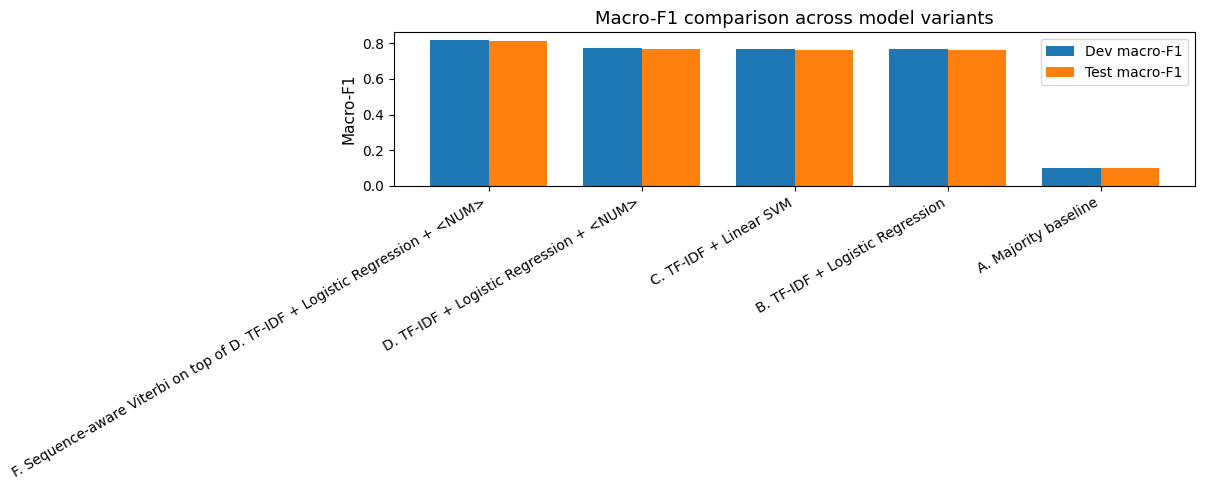

In [30]:
plot_df = results_df.copy()
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, plot_df["dev_macro_f1"], width=width, label="Dev macro-F1")
ax.bar(x + width/2, plot_df["test_macro_f1"], width=width, label="Test macro-F1")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_name"], rotation=30, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1 comparison across model variants")
ax.legend()
plt.tight_layout()
plt.show()

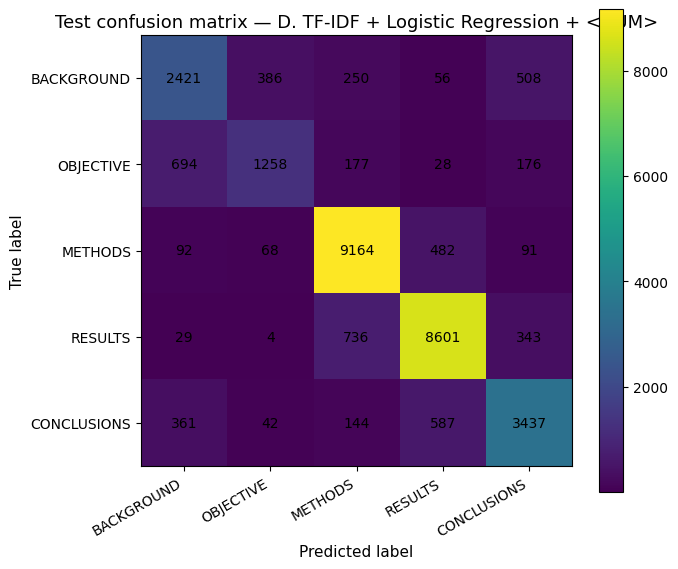

In [31]:
traditional_rows = [row for row in experiment_rows if row["model_name"] in {
    "B. TF-IDF + Logistic Regression",
    "C. TF-IDF + Linear SVM",
    "D. TF-IDF + Logistic Regression + <NUM>",
}]
best_traditional_test = max(traditional_rows, key=lambda x: x["test_macro_f1"])
best_traditional_test_name = best_traditional_test["model_name"]

plot_confusion_matrix(
    test_df["label"],
    saved_predictions[best_traditional_test_name]["test_pred"],
    labels=LABEL_ORDER,
    title=f"Test confusion matrix — {best_traditional_test_name}"
)

In [34]:
advanced_model_name = "E. SciBERT sentence classifier"
if advanced_model_name in saved_predictions:
    plot_confusion_matrix(
        test_df["label"],
        saved_predictions[advanced_model_name]["test_pred"],
        labels=LABEL_ORDER,
        title=f"Test confusion matrix — {advanced_model_name}"
    )
else:
    print("SciBERT confusion matrix not available because the SciBERT run was skipped.")

SciBERT confusion matrix not available because the SciBERT run was skipped.


### E. SciBERT sentence classifier

In [40]:
# Tokenize text for SciBERT model
tokenizer = AutoTokenizer.from_pretrained(SCIBERT_MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=SCIBERT_MAX_LENGTH)

# Prepare training data (potentially a subset)
train_df_scibert = (
    sample_training_subset(train_df, SCIBERT_TRAIN_FRACTION, SEED)
    if USE_SUBSET_FOR_SCIBERT
    else train_df.copy()
)

# Apply preprocessing to create 'text_proc' column
train_df_scibert['text_proc'] = preprocess_text_series(train_df_scibert['text'], number_normalize=True)
dev_df['text_proc'] = preprocess_text_series(dev_df['text'], number_normalize=True)
test_df['text_proc'] = preprocess_text_series(test_df['text'], number_normalize=True)

train_hf_dataset = make_hf_dataset(train_df_scibert, text_col='text_proc')
dev_hf_dataset = make_hf_dataset(dev_df, text_col='text_proc')
test_hf_dataset = make_hf_dataset(test_df, text_col='text_proc')

tokenized_train_ds = train_hf_dataset.map(tokenize_function, batched=True)
tokenized_dev_ds = dev_hf_dataset.map(tokenize_function, batched=True)
tokenized_test_ds = test_hf_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    SCIBERT_MODEL_NAME,
    num_labels=len(LABEL_ORDER),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="max_length", max_length=SCIBERT_MAX_LENGTH)

output_dir = Path("./results")
output_dir.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir=str(output_dir),
    learning_rate=SCIBERT_LR,
    per_device_train_batch_size=SCIBERT_BATCH_SIZE,
    per_device_eval_batch_size=SCIBERT_BATCH_SIZE,
    num_train_epochs=SCIBERT_NUM_EPOCHS,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_epoch=True,
    metric_for_best_model="macro_f1",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_ds,
    eval_dataset=tokenized_dev_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=scibert_compute_metrics,
)

start_train = time.perf_counter()
trainer.train()
train_time = time.perf_counter() - start_train

start_dev = time.perf_counter()
dev_results = trainer.predict(tokenized_dev_ds)
dev_infer = time.perf_counter() - start_dev

start_test = time.perf_counter()
test_results = trainer.predict(tokenized_test_ds)
test_infer = time.perf_counter() - start_test

dev_metrics = dev_results.metrics
test_metrics = test_results.metrics

register_result(
    model_name="E. SciBERT sentence classifier",
    preprocessing="Number normalization + Tokenization",
    uses_sequential="No",
    dev_metrics=dev_metrics,
    test_metrics=test_metrics,
    train_time=train_time,
    dev_infer_time=dev_infer,
    test_infer_time=test_infer,
)

saved_predictions["E. SciBERT sentence classifier"] = {
    "dev_pred": [ID2LABEL[p] for p in dev_results.predictions.argmax(axis=1)],
    "test_pred": [ID2LABEL[p] for p in test_results.predictions.argmax(axis=1)],
}

print_metrics_block("E. SciBERT sentence classifier — dev", dev_metrics)
print_metrics_block("E. SciBERT sentence classifier — test", test_metrics)

Map:   0%|          | 0/63015 [00:00<?, ? examples/s]

Map:   0%|          | 0/30212 [00:00<?, ? examples/s]

Map:   0%|          | 0/30135 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'